In [5]:
%pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

--- Logging error ---
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pip/_internal/utils/logging.py", line 177, in emit
    self.console.print(renderable, overflow="ignore", crop=False, style=style)
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pip/_vendor/rich/console.py", line 1673, in print
    extend(render(renderable, render_options))
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pip/_vendor/rich/console.py", line 1305, in render
    for render_output in iter_render:
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pip/_internal/utils/logging.py", line 134, in __rich_console__
    for line in lines:
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pip/_vendor/rich/segment.py", line 249, in split_lines
    for segment in segments:
  File "/Library/

In [6]:
# Load feature-engineered data
df = pd.read_csv('../dataset/processed/bank_churn_featured.csv')
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Shape: (10000, 21)

Columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Point Earned', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'AgeGroup', 'HasBalance', 'BalancePerProduct', 'IsHighValue', 'ActiveMultiProduct']


In [8]:
# Features for segmentation (excluding target and encoded geography)
segmentation_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 
                         'NumOfProducts', 'EstimatedSalary', 'IsActiveMember']

print("Features used for segmentation:")
for f in segmentation_features:
    print(f"  - {f}")

# Create segmentation dataframe
df_segment = df[segmentation_features].copy()
df_segment.head()

Features used for segmentation:
  - CreditScore
  - Age
  - Tenure
  - Balance
  - NumOfProducts
  - EstimatedSalary
  - IsActiveMember


,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,IsActiveMember
0,619,42,2,0.00,1,101348.88,1
1,608,41,1,83807.86,1,112542.58,1
2,502,42,8,159660.80,3,113931.57,0
3,699,39,1,0.00,2,93826.63,0
4,850,43,2,125510.82,1,79084.10,1


Scale the features

In [9]:
# Initialize scaler
scaler = StandardScaler()

# Fit and transform
df_scaled = scaler.fit_transform(df_segment)

# Convert to dataframe for readability
df_scaled = pd.DataFrame(df_scaled, columns=segmentation_features)

print("Scaled data statistics:")
print(df_scaled.describe().round(2))

Scaled data statistics:
       CreditScore       Age    Tenure   Balance  NumOfProducts  \
count     10000.00  10000.00  10000.00  10000.00       10000.00   
mean         -0.00      0.00     -0.00     -0.00           0.00   
std           1.00      1.00      1.00      1.00           1.00   
min          -3.11     -1.99     -1.73     -1.23          -0.91   
25%          -0.69     -0.66     -0.70     -1.23          -0.91   
50%           0.02     -0.18     -0.00      0.33          -0.91   
75%           0.70      0.48      0.69      0.82           0.81   
max           2.06      5.06      1.72      2.80           4.25   

       EstimatedSalary  IsActiveMember  
count         10000.00        10000.00  
mean             -0.00           -0.00  
std               1.00            1.00  
min              -1.74           -1.03  
25%              -0.85           -1.03  
50%               0.00            0.97  
75%               0.86            0.97  
max               1.74            0.97  


Finding Optimal Number of Clusters using Elbow Method

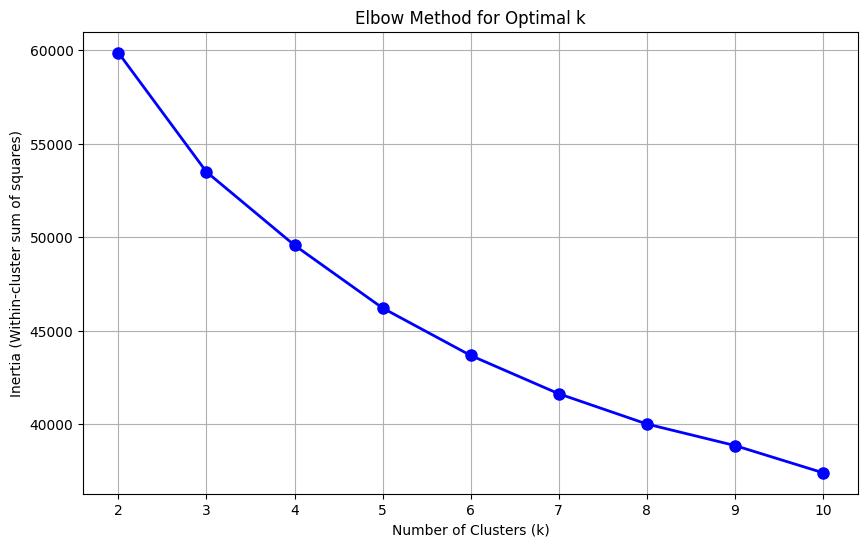

Inertia values:
  k=2: 59856
  k=3: 53483
  k=4: 49560
  k=5: 46203
  k=6: 43666
  k=7: 41619
  k=8: 40001
  k=9: 38850
  k=10: 37395


In [10]:
# Calculating inertia for different k values
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.grid(True)
plt.savefig('../outputs/figures/elbow_curve.png', dpi=300)
plt.show()

print("Inertia values:")
for k, i in zip(k_range, inertia):
    print(f"  k={k}: {i:.0f}")

Finding Optimal Number of Clusters using Silhouette Score 

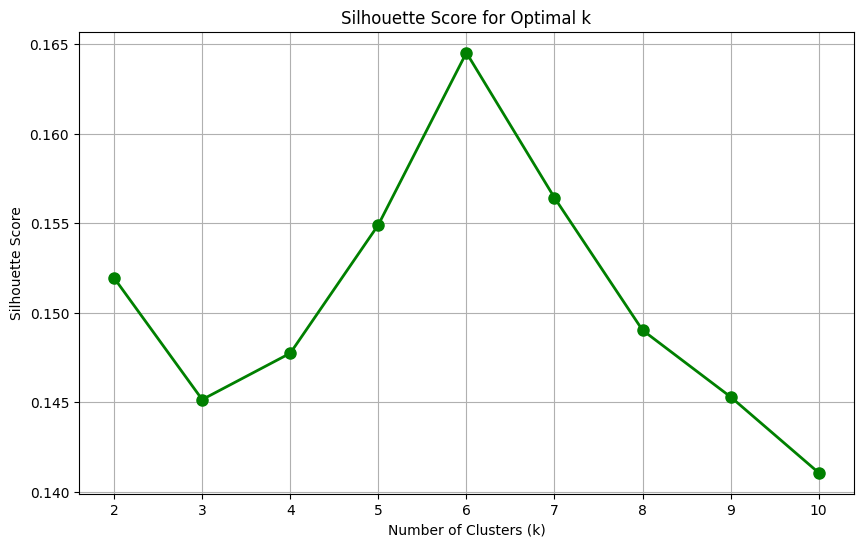

Silhouette scores:
  k=2: 0.1519
  k=3: 0.1452
  k=4: 0.1477
  k=5: 0.1549
  k=6: 0.1645
  k=7: 0.1564
  k=8: 0.1490
  k=9: 0.1453
  k=10: 0.1411

Best k based on silhouette score: 6


In [11]:
# Calculating silhouette scores
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.xticks(k_range)
plt.grid(True)
plt.savefig('../outputs/figures/silhouette_scores.png', dpi=300)
plt.show()

print("Silhouette scores:")
for k, s in zip(k_range, silhouette_scores):
    print(f"  k={k}: {s:.4f}")

best_k = k_range[np.argmax(silhouette_scores)]
print(f"\nBest k based on silhouette score: {best_k}")

In [12]:
# Choosing optimal k = 4 based on elbow and silhouette analysis
optimal_k = 4

print(f"Chosen number of clusters: {optimal_k}")

# Fit final model
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(df_scaled)

print("\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

Chosen number of clusters: 4

Cluster distribution:
Cluster
0    2876
1    2761
2    3247
3    1116
Name: count, dtype: int64


In [13]:
# Choosing optimal k as 6 based on silhouette score
optimal_k = 6

print(f"Chosen number of clusters: {optimal_k}")

# Fit final model
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(df_scaled)

print("\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

Chosen number of clusters: 6

Cluster distribution:
Cluster
0    2505
1    1728
2     961
3    1979
4    1725
5    1102
Name: count, dtype: int64


In [14]:
from sklearn.metrics import silhouette_score

# Try k=4
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_4 = kmeans_4.fit_predict(df_scaled)

# Try k=6
kmeans_6 = KMeans(n_clusters=6, random_state=42, n_init=10)
labels_6 = kmeans_6.fit_predict(df_scaled)

# Add both to dataframe
df['Cluster_4'] = labels_4
df['Cluster_6'] = labels_6

# Compare silhouette scores
print("SILHOUETTE SCORES:")
print(f"  k=4: {silhouette_score(df_scaled, labels_4):.4f}")
print(f"  k=6: {silhouette_score(df_scaled, labels_6):.4f}")

SILHOUETTE SCORES:
  k=4: 0.1477
  k=6: 0.1645


Comparing cluster distributions

In [15]:
print("\n" + "="*50)
print("CLUSTER DISTRIBUTION COMPARISON")
print("="*50)

print("\nk=4 Distribution:")
print(df['Cluster_4'].value_counts().sort_index())

print("\nk=6 Distribution:")
print(df['Cluster_6'].value_counts().sort_index())


CLUSTER DISTRIBUTION COMPARISON

k=4 Distribution:
Cluster_4
0    2876
1    2761
2    3247
3    1116
Name: count, dtype: int64

k=6 Distribution:
Cluster_6
0    2505
1    1728
2     961
3    1979
4    1725
5    1102
Name: count, dtype: int64


Comparing churn rate seperation

In [16]:
print("\n" + "="*50)
print("CHURN RATE COMPARISON")
print("="*50)

# k=4 churn rates
churn_4 = df.groupby('Cluster_4')['Exited'].mean() * 100
print("\nk=4 Churn Rates:")
print(churn_4.round(1))
print(f"Range: {churn_4.min():.1f}% to {churn_4.max():.1f}% (Difference: {churn_4.max() - churn_4.min():.1f}%)")

# k=6 churn rates
churn_6 = df.groupby('Cluster_6')['Exited'].mean() * 100
print("\nk=6 Churn Rates:")
print(churn_6.round(1))
print(f"Range: {churn_6.min():.1f}% to {churn_6.max():.1f}% (Difference: {churn_6.max() - churn_6.min():.1f}%)")


CHURN RATE COMPARISON

k=4 Churn Rates:
Cluster_4
0    13.0
1    11.9
2    28.6
3    36.3
Name: Exited, dtype: float64
Range: 11.9% to 36.3% (Difference: 24.4%)

k=6 Churn Rates:
Cluster_6
0    12.6
1    16.4
2    32.0
3    32.4
4     8.2
5    31.5
Name: Exited, dtype: float64
Range: 8.2% to 32.4% (Difference: 24.3%)


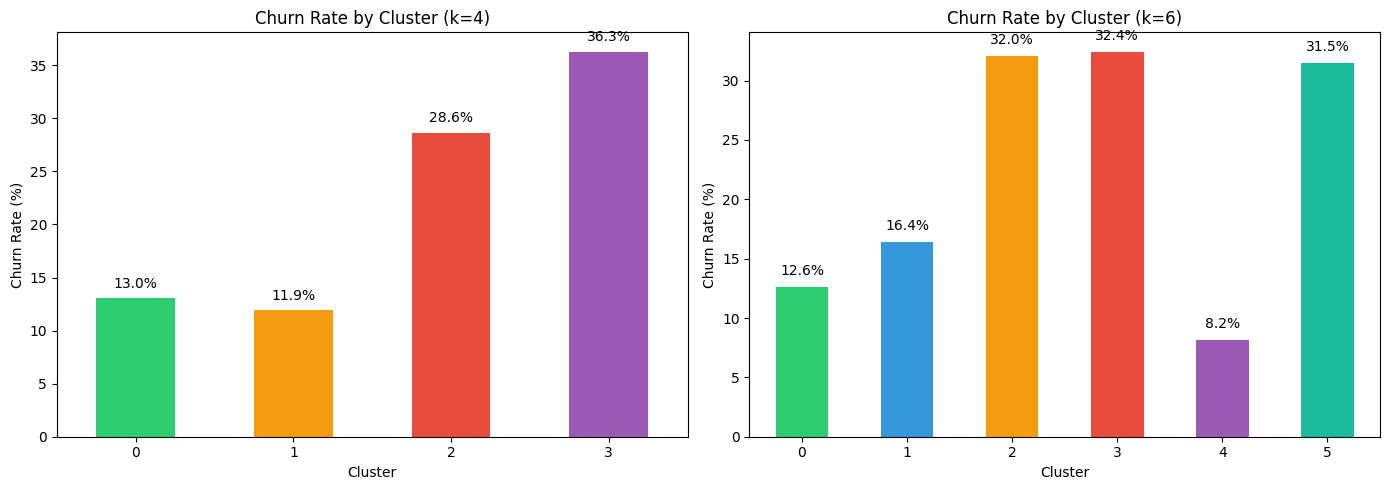

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# k=4
colors_4 = ['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']
churn_4.plot(kind='bar', ax=axes[0], color=colors_4)
axes[0].set_title('Churn Rate by Cluster (k=4)')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Cluster')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(churn_4):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center')

# k=6
colors_6 = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c']
churn_6.plot(kind='bar', ax=axes[1], color=colors_6)
axes[1].set_title('Churn Rate by Cluster (k=6)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('Cluster')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for i, v in enumerate(churn_6):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.savefig('../outputs/figures/k4_vs_k6_comparison.png', dpi=300)
plt.show()

In [18]:
# Using k=4 as final clustering
optimal_k = 4

# Set final cluster labels
df['Cluster'] = df['Cluster_4']

# Drop the comparison columns
df = df.drop(columns=['Cluster_4', 'Cluster_6'])

print(f"Final clustering: k={optimal_k}")
print(f"\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

Final clustering: k=4

Cluster distribution:
Cluster
0    2876
1    2761
2    3247
3    1116
Name: count, dtype: int64


In [19]:
# Full statistics for each cluster
for cluster in range(4):
    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster}")
    print(f"{'='*50}")
    
    cluster_data = df[df['Cluster'] == cluster]
    
    print(f"\nSize: {len(cluster_data)} customers ({len(cluster_data)/len(df)*100:.1f}%)")
    print(f"Churn Rate: {cluster_data['Exited'].mean()*100:.1f}%")
    
    print(f"\nKey Characteristics:")
    print(f"  - Average Age: {cluster_data['Age'].mean():.1f}")
    print(f"  - Average Balance: ${cluster_data['Balance'].mean():,.0f}")
    print(f"  - Average Tenure: {cluster_data['Tenure'].mean():.1f} years")
    print(f"  - Average Products: {cluster_data['NumOfProducts'].mean():.1f}")
    print(f"  - Active Members: {cluster_data['IsActiveMember'].mean()*100:.1f}%")
    print(f"  - Average Salary: ${cluster_data['EstimatedSalary'].mean():,.0f}")
    print(f"  - Average Credit Score: {cluster_data['CreditScore'].mean():.0f}")


CLUSTER 0

Size: 2876 customers (28.8%)
Churn Rate: 13.0%

Key Characteristics:
  - Average Age: 35.3
  - Average Balance: $107,773
  - Average Tenure: 4.8 years
  - Average Products: 1.3
  - Active Members: 100.0%
  - Average Salary: $100,774
  - Average Credit Score: 653

CLUSTER 1

Size: 2761 customers (27.6%)
Churn Rate: 11.9%

Key Characteristics:
  - Average Age: 35.9
  - Average Balance: $9,540
  - Average Tenure: 5.1 years
  - Average Products: 2.1
  - Active Members: 48.9%
  - Average Salary: $99,575
  - Average Credit Score: 650

CLUSTER 2

Size: 3247 customers (32.5%)
Churn Rate: 28.6%

Key Characteristics:
  - Average Age: 37.5
  - Average Balance: $105,903
  - Average Tenure: 5.1 years
  - Average Products: 1.3
  - Active Members: 0.0%
  - Average Salary: $101,699
  - Average Credit Score: 647

CLUSTER 3

Size: 1116 customers (11.2%)
Churn Rate: 36.3%

Key Characteristics:
  - Average Age: 59.9
  - Average Balance: $75,892
  - Average Tenure: 4.9 years
  - Average Product

In [20]:
# Define cluster names
cluster_names = {
    0: 'Active Engaged',
    1: 'Multi-Product Savers',
    2: 'Inactive at Risk',
    3: 'Senior Customers'
}

# Add names to dataframe
df['Cluster_Name'] = df['Cluster'].map(cluster_names)

print("Cluster distribution with names:")
print(df['Cluster_Name'].value_counts())

Cluster distribution with names:
Cluster_Name
Inactive at Risk        3247
Active Engaged          2876
Multi-Product Savers    2761
Senior Customers        1116
Name: count, dtype: int64


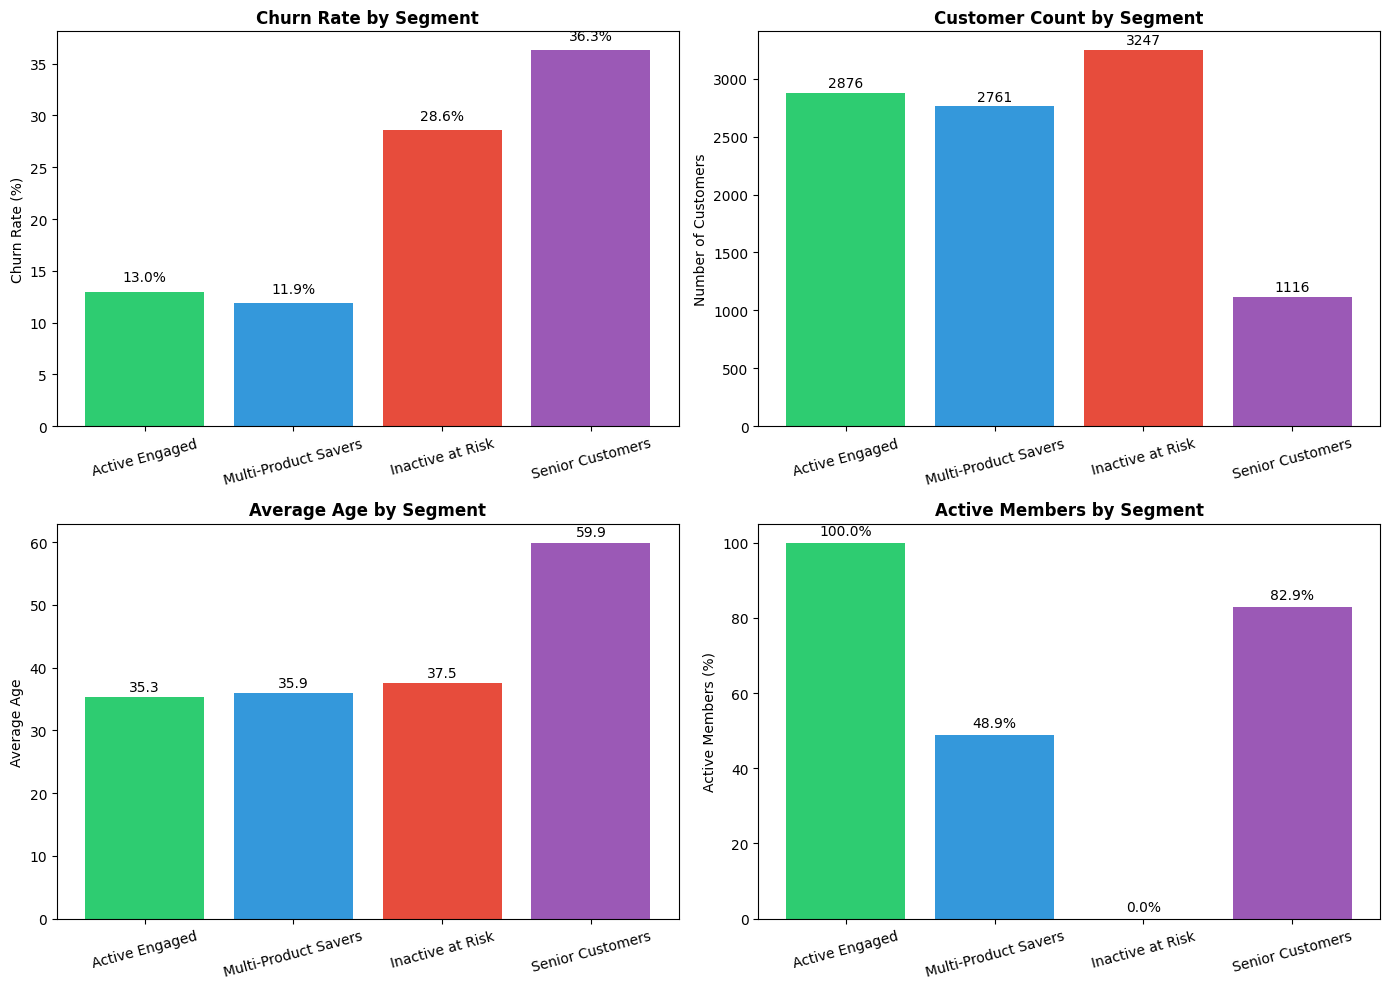

In [21]:
# Create summary visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Churn rate by cluster
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']
churn_rates = df.groupby('Cluster_Name')['Exited'].mean() * 100

ax1 = axes[0, 0]
bars = ax1.bar(cluster_names.values(), [13.0, 11.9, 28.6, 36.3], color=colors)
ax1.set_title('Churn Rate by Segment', fontsize=12, fontweight='bold')
ax1.set_ylabel('Churn Rate (%)')
for i, (bar, val) in enumerate(zip(bars, [13.0, 11.9, 28.6, 36.3])):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val}%', ha='center')
ax1.tick_params(axis='x', rotation=15)

# Customer count by cluster
ax2 = axes[0, 1]
counts = [2876, 2761, 3247, 1116]
bars = ax2.bar(cluster_names.values(), counts, color=colors)
ax2.set_title('Customer Count by Segment', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Customers')
for bar, val in zip(bars, counts):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 50, f'{val}', ha='center')
ax2.tick_params(axis='x', rotation=15)

# Average age by cluster
ax3 = axes[1, 0]
ages = [35.3, 35.9, 37.5, 59.9]
bars = ax3.bar(cluster_names.values(), ages, color=colors)
ax3.set_title('Average Age by Segment', fontsize=12, fontweight='bold')
ax3.set_ylabel('Average Age')
for bar, val in zip(bars, ages):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}', ha='center')
ax3.tick_params(axis='x', rotation=15)

# Active member percentage by cluster
ax4 = axes[1, 1]
active_pct = [100.0, 48.9, 0.0, 82.9]
bars = ax4.bar(cluster_names.values(), active_pct, color=colors)
ax4.set_title('Active Members by Segment', fontsize=12, fontweight='bold')
ax4.set_ylabel('Active Members (%)')
for bar, val in zip(bars, active_pct):
    ax4.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val}%', ha='center')
ax4.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../outputs/figures/cluster_summary.png', dpi=300)
plt.show()

In [ ]:
"""
============================================================
RETENTION STRATEGIES BY SEGMENT
============================================================

CLUSTER 0: Active Engaged (13% churn)
-----------------------------------------
Risk Level: LOW
Strategy: Maintain engagement
Actions:
  - Reward loyalty with exclusive offers
  - Cross-sell additional products
  - Keep them active with regular communication

CLUSTER 1: Multi-Product Savers (11.9% churn)
-----------------------------------------
Risk Level: LOWEST
Strategy: Protect and grow
Actions:
  - These are your best customers - don't lose them
  - Increase engagement to boost activity (only 49% active)
  - Encourage higher balances with savings incentives

CLUSTER 2: Inactive at Risk (28.6% churn) ⚠️
-----------------------------------------
Risk Level: HIGH - PRIORITY SEGMENT
Strategy: Re-engagement campaign
Actions:
  - URGENT: 0% active members, 29% churning
  - Launch re-activation campaigns immediately
  - Personal outreach from relationship managers
  - Offer incentives to use accounts
  - This is your biggest segment (32.5%) - high impact potential

CLUSTER 3: Senior Customers (36.3% churn) ⚠️
-----------------------------------------
Risk Level: HIGHEST
Strategy: Specialized senior care
Actions:
  - Highest churn rate - needs immediate attention
  - Offer senior-specific products and benefits
  - Simplified banking options
  - Dedicated support line for seniors
  - Consider wealth management services

============================================================
PRIORITY ORDER:
1. Cluster 2 (Inactive at Risk) - Largest high-risk group
2. Cluster 3 (Senior Customers) - Highest churn rate
3. Cluster 1 (Multi-Product Savers) - Protect best customers
4. Cluster 0 (Active Engaged) - Maintain status quo
============================================================
"""

Summary

============================================================
CUSTOMER SEGMENTATION SUMMARY
============================================================

Method: K-Means Clustering (k=4)
Silhouette Score: 0.148

SEGMENTS IDENTIFIED:
--------------------
1. Active Engaged (28.8%) - 13.0% churn
   Young, active, good balance

2. Multi-Product Savers (27.6%) - 11.9% churn
   Multiple products, low balance, lowest risk

3. Inactive at Risk (32.5%) - 28.6% churn
   0% active, good balance, HIGH RISK

4. Senior Customers (11.2%) - 36.3% churn
   Older customers, HIGHEST RISK

KEY INSIGHT:
------------
Activity status is the strongest differentiator.
Inactive customers churn at 2x the rate of active customers.

BUSINESS IMPACT:
----------------
- Focus retention on Clusters 2 and 3
- Re-activate inactive customers (Cluster 2)
- Develop senior-specific programs (Cluster 3)
============================================================